In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("/home/jvierstra/proj/vinson")

In [63]:
import configparser
import pickle

import numpy as np
import pandas as pd
import scipy.stats

from genome_tools.data.anndata import read_zarr_backed

In [3]:
nmf_config_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/embeddings/NMF/latest/nmf_config.ini"

config = configparser.ConfigParser()
config.read(nmf_config_file)

['/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/embeddings/NMF/latest/nmf_config.ini']

In [959]:
dnase_adata = read_zarr_backed(config["NMF"]["anndata"])

In [1080]:
labels_df = (
    dnase_adata.obs.groupby(["core_annotation", "extended_annotation"])
    .filter(lambda x: len(x) >= 5)[["core_annotation", "extended_annotation", "pathological_state"]]
    .rename(
        columns={
            "core_annotation": "core_annotation",
            "extended_annotation": "extended_annotation",
            "pathological_state": "disease_state",
        }
    )
)

labels_df["cell_type"] = labels_df["core_annotation"].astype(str) + "_" + labels_df["extended_annotation"].astype(str)
labels_df.head()

/tmp/ipykernel_57158/3323266269.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dnase_adata.obs.groupby(["core_annotation", "extended_annotation"])


,core_annotation,extended_annotation,disease_state,cell_type
ag_id,,,,
AG10028,Myeloid,CML,Cancer,Myeloid_CML
AG10029,Myeloid,CML,Cancer,Myeloid_CML
AG10031,Myeloid,CML,Cancer,Myeloid_CML
AG10032,Myeloid,CML,Cancer,Myeloid_CML
AG10033,Myeloid,CML,Cancer,Myeloid_CML


In [1081]:
with open(
    "/home/aabisheva/public_html/motif_data/cluster_matrices_unique.pkl", "rb"
) as f:
    data = pickle.load(f)
    human_embedding = data["human_cluster_median"].T
    human_embedding.index.rename("ag_id", inplace=True)
    human_embedding.columns.rename("motif_cluster", inplace=True)

    mouse_embedding = data["mouse_cluster_median"].T
    mouse_embedding.index.rename("ag_id", inplace=True)
    mouse_embedding.columns.rename("motif_cluster", inplace=True)


print(human_embedding.shape)
print(mouse_embedding.shape)


def zscore_normalization(x, eta=1e-5):
    x = np.log(x + eta)
    return (x - x.mean()) / x.std()


human_normed_embedding = human_embedding.apply(zscore_normalization, axis=1)
human_normed_embedding = human_normed_embedding.loc[labels_df.index]

mouse_normed_embedding = mouse_embedding.apply(zscore_normalization, axis=1)

(4159, 637)
(537, 637)


In [1082]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

embed_train, embed_valid, labels_train, labels_valid = train_test_split(
    human_normed_embedding,
    labels_df,
    test_size=0.2,
    stratify=labels_df.cell_type,
    random_state=0,
)

In [1083]:
from vinson.datasets.cell_classifier import EncoderDataset

encoders = {col: LabelEncoder().fit(labels_df[col]) for col in labels_df.columns}

ds_train = EncoderDataset(embed_train, labels_train, encoders=encoders)
ds_valid = EncoderDataset(embed_valid, labels_valid, encoders=encoders)

In [1084]:
import torch
from torch.utils.data import DataLoader

train_dataloader = DataLoader(ds_train, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(ds_valid, batch_size=32)

In [1085]:
from vinson.models.cell_classifier import CellAndDiseaseStateClassifierModel

model = CellAndDiseaseStateClassifierModel(
    human_normed_embedding.shape[1],
    n_cell_types=len(encoders["cell_type"].classes_),
    n_disease_states=len(encoders["disease_state"].classes_),
)

In [1086]:
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor="val_loss", mode="min", min_delta=0.0001, patience=10)
model_checkpoint = ModelCheckpoint(
    monitor='val_loss',
    mode='min',
    save_top_k=1,
)

callbacks = [
    early_stopping,
    model_checkpoint,
]

trainer = L.Trainer(max_epochs=200, callbacks=callbacks, accelerator="cpu")
trainer.fit(model, train_dataloader, valid_dataloader)

/home/jvierstra/.local/miniconda3/envs/tf-2.13.0/lib/python3.9/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jvierstra/.local/miniconda3/envs/tf-2.13.0/lib ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/jvierstra/.local/miniconda3/envs/tf-2.13.0/lib/python3.9/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /home/jvierstra/proj/vinson/notebooks/lightning_logs/version_29227708/checkpoints exists and is not empty.

  | Name               | Type             | Params | Mode 
----------------------------------------------------------------
0 | trunk              | EmbeddingMLP     | 45.2 K | train
1 | head_cell_type     | Linear           | 3.4 K  | train
2 | head_disease_state 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [1087]:
model.load_state_dict(torch.load(model_checkpoint.best_model_path)["state_dict"])
model = model.eval()

In [1088]:
labels_cell_type, labels_disease_state = [], []
p_cell_type, p_disease_state = [], []

with torch.no_grad():
    for batch in valid_dataloader:
        X = batch["embed"]
        y_cell_type = batch["cell_type"]
        y_disease_state = batch["disease_state"]
        _y_cell_type, _y_disease_state = model(X)

        labels_cell_type.append(y_cell_type.cpu().numpy())
        labels_disease_state.append(y_disease_state.cpu().numpy())

        p_cell_type.append(torch.softmax(_y_cell_type, dim=-1).cpu().numpy())
        p_disease_state.append(torch.softmax(_y_disease_state, dim=-1).cpu().numpy())

labels_cell_type = np.concatenate(labels_cell_type)
labels_disease_state = np.concatenate(labels_disease_state)

p_cell_type = np.vstack(p_cell_type)
p_disease_state = np.vstack(p_disease_state)

In [1089]:
labels_cell_type_ohe = np.eye(len(encoders["cell_type"].classes_))[labels_cell_type]
labels_disease_state_ohe = np.eye(len(encoders["disease_state"].classes_))[
    labels_disease_state
]

Text(0.5, 1.0, 'Adipose_Liposarcoma\n(n=2)')

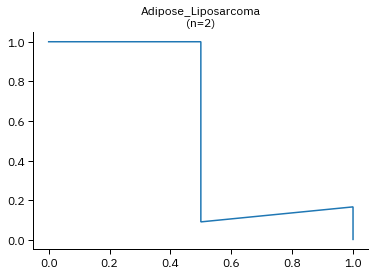

In [1090]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

i = 1

cell_type = encoders["cell_type"].classes_[i]
n = labels_cell_type_ohe[:, i].sum()

precision, recall, thresholds = precision_recall_curve(
    labels_cell_type_ohe[:, i], p_cell_type[:, i]
)

thresholds = np.append(thresholds, 1.0)
f1 = (2 * precision * recall) / (precision + recall + 1e-8)


plt.plot(recall, precision)
plt.title(f"{cell_type}\n(n={int(n)})")

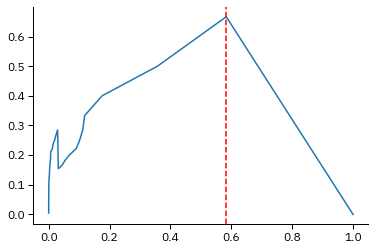

In [1091]:
i = np.argmax(f1)
plt.plot(thresholds, f1)
plt.axvline(thresholds[i], color="red", ls="--")

(-0.05, 1.05)

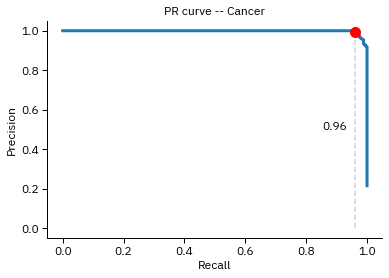

In [1138]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["font.sans-serif"] = ["IBM Plex Sans"]


from sklearn.metrics import precision_recall_curve

i = 0

precision, recall, thresholds = precision_recall_curve(
    labels_disease_state_ohe[:, i], p_disease_state[:, i]
)
thresholds = np.append(thresholds, 1.0)

thresh_i = np.where(precision >= 0.99)[0][0]
threshold_cancer = thresholds[thresh_i]

plt.plot(recall, precision, lw=3)
plt.scatter(recall[thresh_i], precision[thresh_i], color="red", zorder=10, s=100)

plt.vlines(recall[thresh_i], ymin=0, ymax=precision[thresh_i], color="lightgrey", ls="--")
plt.text(recall[thresh_i]-0.025, 0.5, f"{recall[thresh_i]:0.2f}", ha="right", fontsize="large")

plt.title("PR curve -- Cancer")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.ylim(bottom=-0.05)

In [1139]:
threshold_cancer

0.8927614688873291

In [1094]:
labels_df["col"] = encoders["cell_type"].transform(labels_df.cell_type)

map_dict = {}

for core_annotation, cols in labels_df.groupby("core_annotation")["col"]:
    uniq_cols = cols.unique()
    if len(uniq_cols) > 0:
        map_dict[core_annotation] = uniq_cols

p_core_annotation_df = pd.DataFrame({k: p_cell_type[:, v].sum(axis=1) for k, v in map_dict.items()})
labels_core_annotation_ohe_df = pd.DataFrame({k: labels_cell_type_ohe[:, v].max(axis=1) for k, v in map_dict.items()})


cols = encoders["cell_type"].inverse_transform(np.arange(p_cell_type.shape[1]))
p_cell_type_df = pd.DataFrame(p_cell_type, columns=cols)
labels_cell_type_ohe_df = pd.DataFrame(labels_cell_type_ohe, columns=cols)

/tmp/ipykernel_57158/2334752633.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for core_annotation, cols in labels_df.groupby("core_annotation")["col"]:


In [1327]:
def get_classification_thresholds(y_true, y_pred, min_precision=0.975, min_thresh=0.5):
    """ """
    thresholds_dict = {}
    
    for cat in y_true.columns:
        precision, recall, thresholds = precision_recall_curve(
            y_true[cat], y_pred[cat]
        )
        thresholds = np.append(thresholds, 1.0)

        pr_curve = pd.DataFrame(
            {
                "p": precision,
                "r": recall,
                "t": thresholds,
                "f1": (2 * precision * recall) / (precision + recall + 1e-8),
            }
        )
        
        subset = pr_curve.query("p >= @min_precision and t >=  @min_thresh")
        if subset.empty:
            thresholds_dict[cat] = 1.0
        else:
            thresh_i = subset["f1"].idxmax()
            thresholds_dict[cat] = thresholds[thresh_i]

    return thresholds_dict
    
thresholds_core_annotation = get_classification_thresholds(labels_core_annotation_ohe_df, p_core_annotation_df, min_precision=0.95)
thresholds_cell_type = get_classification_thresholds(labels_cell_type_ohe_df, p_cell_type_df, min_precision=0.95)

(-0.05, 1.049329268292683)

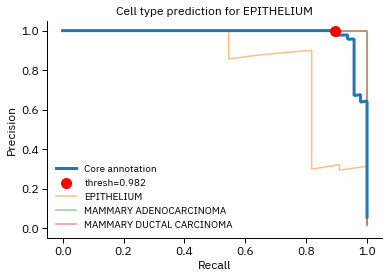

In [1368]:
annotation = "Epithelium"

precision, recall, thresholds = precision_recall_curve(
    labels_core_annotation_ohe_df[annotation], p_core_annotation_df[annotation]
)
thresholds = np.append(thresholds, 1.0)

pr_curve = pd.DataFrame(
    {
        "p": precision,
        "r": recall,
        "t": thresholds,
        "f1": (2 * precision * recall) / (precision + recall + 1e-8),
    }
)
thresh_i = pr_curve.query("p >= 0.99 and t >= 0.5")["f1"].idxmax()
# print(thresholds[thresh_i])

plt.plot(recall, precision, lw=3, label="Core annotation")
plt.scatter(recall[thresh_i], precision[thresh_i], color="red", zorder=10, s=100, label=f"thresh={thresholds[thresh_i]:0.3f}")

for i in map_dict[annotation]:
    precision, recall, thresholds = precision_recall_curve(
        labels_cell_type_ohe[:, i], p_cell_type[:, i]
    )
    thresholds = np.append(thresholds, 1.0)

    pr_curve = pd.DataFrame(
        {
            "p": precision,
            "r": recall,
            "t": thresholds,
            "f1": (2 * precision * recall) / (precision + recall + 1e-8),
        }
    )
    thresh_i = pr_curve.query("p >= 0.95 and t >= 0.5")["f1"].idxmax()
    # print(thresholds[thresh_i])

    plt.plot(recall, precision, alpha=0.5, label=encoders["cell_type"].classes_[i].split("_")[1].upper(), zorder=-1)    

plt.legend()

plt.title(f"Cell type prediction for {annotation.upper()}")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.ylim(bottom=-0.05)

## Public ATAC-seq

In [1208]:
human_embedding_atac = pd.read_table('/net/seq/data2/projects/aabisheva/DHS_evolution/benchmark/hg38/tf_motif_v23_v2_p1e_minus_5_atac/results/normalized/atac_motif_proportions.tsv').set_index('motif_id')
human_embedding_atac = human_embedding_atac

motif_meta = pd.read_table('/net/seq/data2/projects/sabramov/ENCODE4/motifs_metadata.annotated.tsv').set_index('motif_id')
human_embedding_atac['motif_cluster'] = motif_meta['unique_cluster_name']

human_embedding_atac = human_embedding_atac.groupby('motif_cluster').agg('median').T
human_normed_embedding_atac = human_embedding_atac.apply(zscore_normalization, axis=1)

assert all(human_normed_embedding_atac.columns == human_normed_embedding.columns), "Column order doesn't match training data!"

In [1098]:
human_normed_embedding_atac.values

def split_batches(x, batch_size=128):
    batches = np.array_split(x, np.arange(batch_size, len(x), batch_size))
    return batches

batches = split_batches(human_normed_embedding_atac.values)

In [1329]:
p_cell_type_atac, p_disease_state_atac = [], []

with torch.no_grad():
    for batch in batches:
        _y_cell_type, _y_disease_state = model(torch.tensor(batch).to(torch.float32))
        p_cell_type_atac.append(torch.softmax(_y_cell_type, dim=-1).cpu().numpy())
        p_disease_state_atac.append(torch.softmax(_y_disease_state, dim=-1).cpu().numpy())

p_cell_type_atac = np.vstack(p_cell_type_atac)
p_disease_state_atac = np.vstack(p_disease_state_atac)

p_cell_type_atac_df = pd.DataFrame(p_cell_type_atac, columns=cols, index=human_normed_embedding_atac.index)
p_core_annotation_atac_df = pd.DataFrame({k: p_cell_type_atac[:, v].sum(axis=1) for k, v in map_dict.items()}, index=human_normed_embedding_atac.index)

In [1373]:
print(f"Number of cancer: {(p_disease_state_atac[:,0] >= threshold_cancer).sum()}")

Number of cancer: 1982


In [1331]:
pred_cell_type_atac = pd.DataFrame(
    np.vstack(
        [
            p_cell_type_atac_df[col] >= thresholds_cell_type[col] 
            for col in p_cell_type_atac_df.columns
        ]).T,
    columns=cols, 
    index=human_normed_embedding_atac.index,
    dtype=int,
)

pred_core_annotation_atac = pd.DataFrame(
    np.vstack(
        [
            p_core_annotation_atac_df[col] >= thresholds_core_annotation[col] 
            for col in p_core_annotation_atac_df.columns
        ]).T,
    columns=p_core_annotation_atac_df.columns, 
    index=human_normed_embedding_atac.index,
    dtype=int,
)

In [1338]:
pred_cell_type_atac.sum(axis=0)

Adipose_Adipose                                                       0
Adipose_Liposarcoma                                                   0
Adrenal_Adrenal                                                      12
Bone_Sarcoma                                                          0
Brain_Basal ganglia                                                  89
Brain_Blastoma                                                        0
Brain_Brain stem                                                      0
Brain_Cerebellum                                                      1
Brain_Cerebral cortex                                                91
Brain_Limbic system                                                  11
Brain_Spinal cord                                                    13
Colon_Carcinoma                                                     122
Colon_Colon                                                          11
Endothelium_Endothelium                                         

In [1333]:
has_cell_type = pred_cell_type_atac.sum(axis=1) > 0
has_core_annotation = pred_core_annotation_atac.sum(axis=1) > 0

has_core_annotation.sum(), has_cell_type.sum()

(7071, 5116)

In [1353]:
# TODO: return likely cell types, when core prediction is
# significant, but no clear individual extended annotation

samples_to_refine = has_core_annotation.values & ~has_cell_type.values 

z = pred_core_annotation_atac[samples_to_refine].idxmax(axis=1)

for i, core_annotation in z.items():
    c =  p_cell_type_atac_df.columns.str.contains(core_annotation)
    s = p_cell_type_atac_df.loc[i, c]
    s /= s.sum()
    #print(s.sort_values(ascending=False))

## Mouse

In [1355]:
with torch.no_grad():
    _y_cell_type_mouse, _y_disease_state_mouse = model(torch.tensor(mouse_normed_embedding.values).to(torch.float32))

In [1363]:
mouse_metadata = pd.read_table("/net/seq/data2/projects/acote/projects/encode4/hs3_index/metadata/mouse/mouse_metadata_250820JVsysupdate.tsv", index_col=0)
mouse_metadata = mouse_metadata.loc[mouse_normed_embedding.index]
mouse_metadata.head()

,experiment_accession,tc_number,ds_number,ln_number,core_annotation,extended_annotation,biosample_type,system,growth_stage,state,...,non_mapped,nuclear_align,filtered_aligned,peaks_for_index,peaks_for_matrix,peak_stats,normalized_density_bw,perc_dup,total_fastq_reads,alignment_quality
ag_id,,,,,,,,,,,,,,,,,,,,,
AG2201,ENCSR998KYQ,TC24418,DS22742,LN20370,Adipose,Adipose,Cultured,Integumentary,Postnatal,Immortalized cell line,...,4892296,94375348,95062087,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,0.073814,120834465,0.781030
AG2204,ENCSR687EAW,TC24419,DS22642,LN20344,Adipose,Adipose,Cultured,Integumentary,Postnatal,Immortalized cell line,...,5297708,31693099,38086882,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,0.095440,63504418,0.499069
AG82359,ENCSR822RKU,TC12178,DS77105,LN60232,Adrenal,Adrenal,Tissue,Endocrine,Postnatal,Whole tissue,...,11364764,151205856,151520996,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,0.236400,196490450,0.769533
AG82346,ENCSR840HMW,TC12211,DS83185,LN65838,Adrenal,Adrenal,Tissue,Endocrine,Postnatal,Whole tissue,...,74918768,115608142,115706942,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,0.293021,229437560,0.503876
AG82344,ENCSR831ITR,TC12222,DS83196,LN65845,Adrenal,Adrenal,Tissue,Endocrine,Postnatal,Whole tissue,...,117399684,239181334,241181402,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,/net/seq/data2/projects/ENCODE4Plus/hotspot3/m...,0.307220,413424082,0.578537


In [1372]:
mouse_cell_type_preds = pd.DataFrame(
    {
        "taxonomy_name": mouse_metadata.taxonomy_name, 
        "extended_annotation": mouse_metadata.extended_annotation,
        "pred": encoders["cell_type"].inverse_transform(_y_cell_type_mouse.argmax(dim=-1).cpu().numpy())
    }
)
mouse_cell_type_preds.head(n=20)

,taxonomy_name,extended_annotation,pred
ag_id,,,
AG2201,mAdipocyte,Adipose,Heart_Heart
AG2204,mPre-adipocyte,Adipose,Melanocyte_Melanocyte
AG82359,m.adrenal,Adrenal,Adrenal_Adrenal
AG82346,m.adrenal,Adrenal,Brain_Cerebral cortex
AG82344,m.adrenal,Adrenal,Adrenal_Adrenal
AG82336,m.adrenal,Adrenal,Adrenal_Adrenal
AG82333,m.adrenal,Adrenal,Adrenal_Adrenal
AG82330,m.adrenal,Adrenal,Adrenal_Adrenal
AG82328,m.adrenal,Adrenal,Adrenal_Adrenal
